# DSBDA Lab Assignment No. 9
## Data Visualisation II — Iris Dataset (Box Plot)
**Department of Computer Engineering**

**Title:** Data Visualisation II  
**Dataset:** Iris (inbuilt — `sns.load_dataset('iris')`)  
**Objective:** Use box plots to analyze and visualize the distribution of features across the three Iris flower species to find patterns in the data.

---
## Theory

### Box Plot
A box plot (also called a box-and-whisker plot) is used to display the distribution of a numerical variable using five summary statistics:

| Component | Description |
|---|---|
| **Minimum** | Lowest value excluding outliers (lower whisker) |
| **Q1 (25th percentile)** | Bottom edge of the box |
| **Median (Q2)** | Line inside the box |
| **Q3 (75th percentile)** | Top edge of the box |
| **Maximum** | Highest value excluding outliers (upper whisker) |
| **IQR** | Interquartile Range = Q3 − Q1 (height of the box) |
| **Outliers** | Points beyond 1.5 × IQR from Q1 or Q3, shown as dots |

Box plots are especially useful when comparing distributions across **multiple categories** (e.g., species).

---
## 1. Imports and Dataset Loading

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (8, 5)

---
## 2. Know Your Data

In [4]:
# Load inbuilt Iris dataset
dataset = sns.load_dataset('iris')

print(f"Shape: {dataset.shape}")
print(f"Rows: {dataset.shape[0]}, Columns: {dataset.shape[1]}")
dataset.head(10)

Shape: (150, 5)
Rows: 150, Columns: 5


,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa
5,5.4,3.9,1.7,0.4,setosa
6,4.6,3.4,1.4,0.3,setosa
7,5.0,3.4,1.5,0.2,setosa
8,4.4,2.9,1.4,0.2,setosa
9,4.9,3.1,1.5,0.1,setosa


In [5]:
# Dataset info — column types and null check
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB


In [6]:
# Check for null values
print("Null values per column:")
print(dataset.isnull().sum())

Null values per column:
sepal_length    0
sepal_width     0
petal_length    0
petal_width     0
species         0
dtype: int64


In [7]:
# Class distribution
print("Species distribution:")
print(dataset['species'].value_counts())

Species distribution:
species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64


In [8]:
# Statistical summary
dataset.describe()

,sepal_length,sepal_width,petal_length,petal_width
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333
std,0.828066,0.435866,1.765298,0.762238
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


**Dataset Overview:**
- 150 rows, 5 columns
- 4 numeric features: `sepal_length`, `sepal_width`, `petal_length`, `petal_width`
- 1 categorical target: `species` — with 3 classes: *setosa*, *versicolor*, *virginica* (50 samples each)
- No missing values

---
## 3. Box Plot Analysis

### Plot 1 — Sepal Length by Species

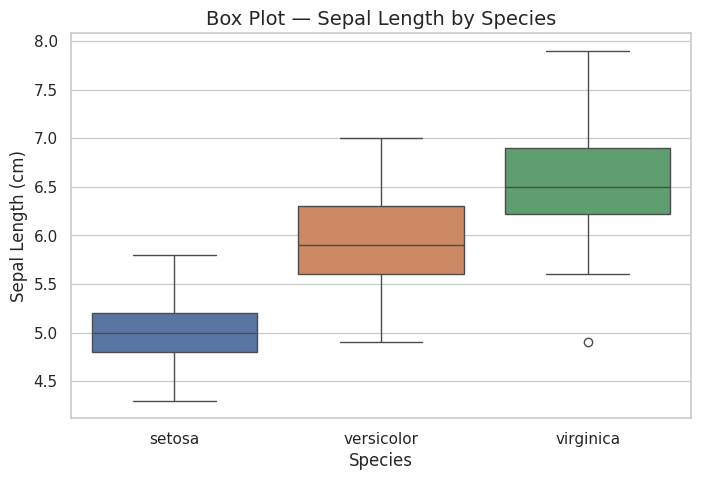

Observations:
  - Virginica has the largest sepal length (median ~6.5 cm).
  - Setosa has the shortest sepal length (median ~5.0 cm).
  - Versicolor sits in between (~5.9 cm median).
  - All three species are clearly separable on sepal length.


In [9]:
plt.figure(figsize=(8, 5))
sns.boxplot(x='species', y='sepal_length', data=dataset,
            palette=['#4C72B0', '#DD8452', '#55A868'])
plt.title('Box Plot — Sepal Length by Species', fontsize=14)
plt.xlabel('Species')
plt.ylabel('Sepal Length (cm)')
plt.show()

print("Observations:")
print("  - Virginica has the largest sepal length (median ~6.5 cm).")
print("  - Setosa has the shortest sepal length (median ~5.0 cm).")
print("  - Versicolor sits in between (~5.9 cm median).")
print("  - All three species are clearly separable on sepal length.")

### Plot 2 — Sepal Width by Species

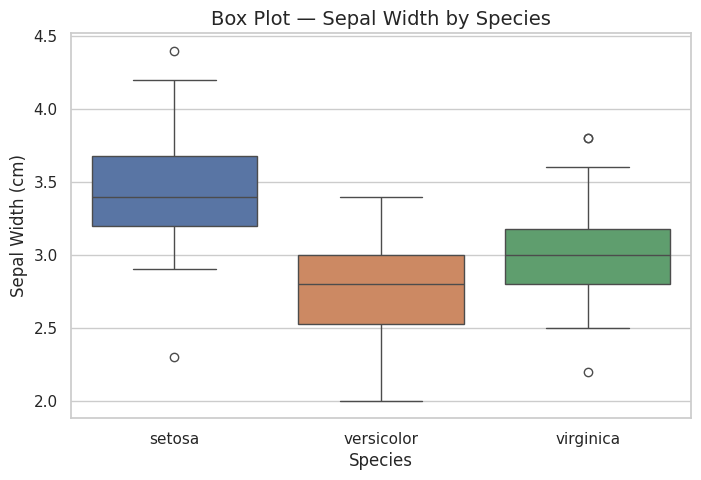

Observations:
  - Setosa has the widest sepals (median ~3.4 cm) with several outliers.
  - Versicolor and Virginica have similar, narrower sepal widths (~2.8–3.0 cm).
  - Sepal width alone is NOT a good feature to separate versicolor from virginica.


In [10]:
plt.figure(figsize=(8, 5))
sns.boxplot(x='species', y='sepal_width', data=dataset,
            palette=['#4C72B0', '#DD8452', '#55A868'])
plt.title('Box Plot — Sepal Width by Species', fontsize=14)
plt.xlabel('Species')
plt.ylabel('Sepal Width (cm)')
plt.show()

print("Observations:")
print("  - Setosa has the widest sepals (median ~3.4 cm) with several outliers.")
print("  - Versicolor and Virginica have similar, narrower sepal widths (~2.8–3.0 cm).")
print("  - Sepal width alone is NOT a good feature to separate versicolor from virginica.")

### Plot 3 — Petal Length by Species

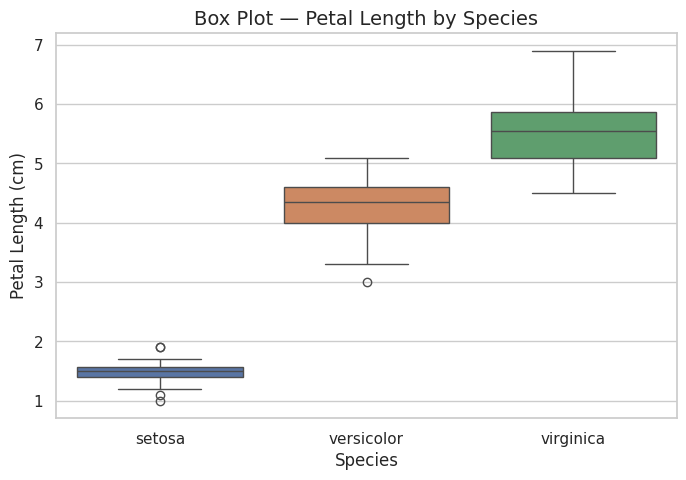

Observations:
  - Setosa has very short petals (median ~1.5 cm) with extremely low variance.
  - Virginica has the longest petals (median ~5.5 cm).
  - Petal length is the BEST single feature for species classification.
  - The three species are clearly separated with minimal overlap.


In [11]:
plt.figure(figsize=(8, 5))
sns.boxplot(x='species', y='petal_length', data=dataset,
            palette=['#4C72B0', '#DD8452', '#55A868'])
plt.title('Box Plot — Petal Length by Species', fontsize=14)
plt.xlabel('Species')
plt.ylabel('Petal Length (cm)')
plt.show()

print("Observations:")
print("  - Setosa has very short petals (median ~1.5 cm) with extremely low variance.")
print("  - Virginica has the longest petals (median ~5.5 cm).")
print("  - Petal length is the BEST single feature for species classification.")
print("  - The three species are clearly separated with minimal overlap.")

### Plot 4 — Petal Width by Species

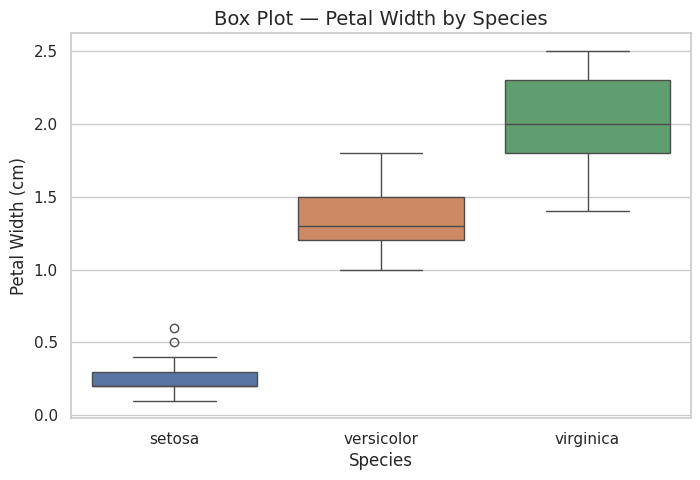

Observations:
  - Setosa has the narrowest petals (median ~0.2 cm) — very tight IQR.
  - Virginica has the widest petals (median ~2.0 cm).
  - Like petal length, petal width also separates species well.
  - Small overlap between versicolor and virginica exists.


In [12]:
plt.figure(figsize=(8, 5))
sns.boxplot(x='species', y='petal_width', data=dataset,
            palette=['#4C72B0', '#DD8452', '#55A868'])
plt.title('Box Plot — Petal Width by Species', fontsize=14)
plt.xlabel('Species')
plt.ylabel('Petal Width (cm)')
plt.show()

print("Observations:")
print("  - Setosa has the narrowest petals (median ~0.2 cm) — very tight IQR.")
print("  - Virginica has the widest petals (median ~2.0 cm).")
print("  - Like petal length, petal width also separates species well.")
print("  - Small overlap between versicolor and virginica exists.")

### Plot 5 — All Four Features Side by Side (Subplot Grid)

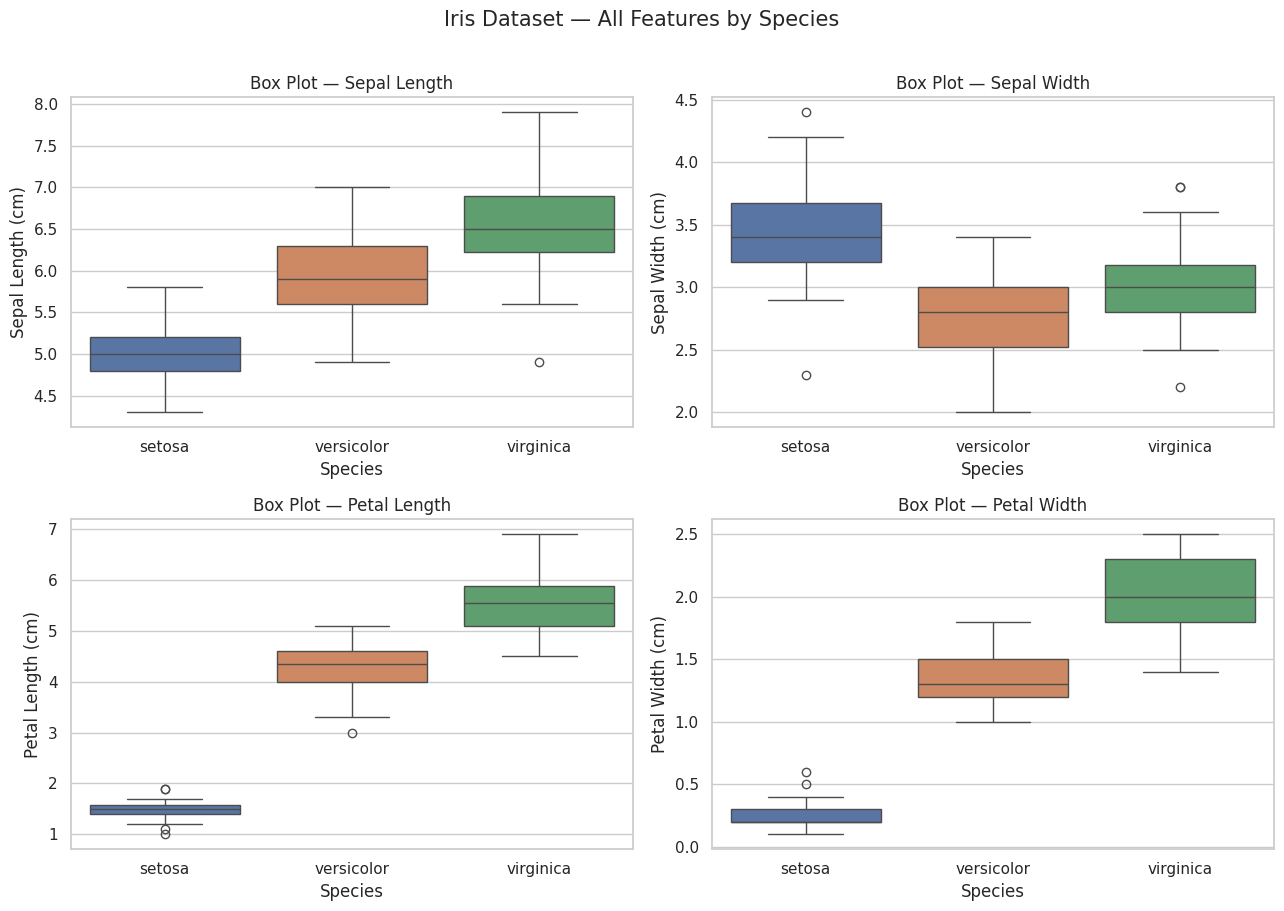

In [13]:
features = ['sepal_length', 'sepal_width', 'petal_length', 'petal_width']
titles   = ['Sepal Length', 'Sepal Width', 'Petal Length', 'Petal Width']
palette  = ['#4C72B0', '#DD8452', '#55A868']

fig, axes = plt.subplots(2, 2, figsize=(13, 9))
axes = axes.flatten()

for i, (feat, title) in enumerate(zip(features, titles)):
    sns.boxplot(x='species', y=feat, data=dataset,
                palette=palette, ax=axes[i])
    axes[i].set_title(f'Box Plot — {title}', fontsize=12)
    axes[i].set_xlabel('Species')
    axes[i].set_ylabel(f'{title} (cm)')

plt.suptitle('Iris Dataset — All Features by Species', fontsize=15, y=1.01)
plt.tight_layout()
plt.show()

### Plot 6 — Box Plot with Outlier Highlight (`flierprops`)

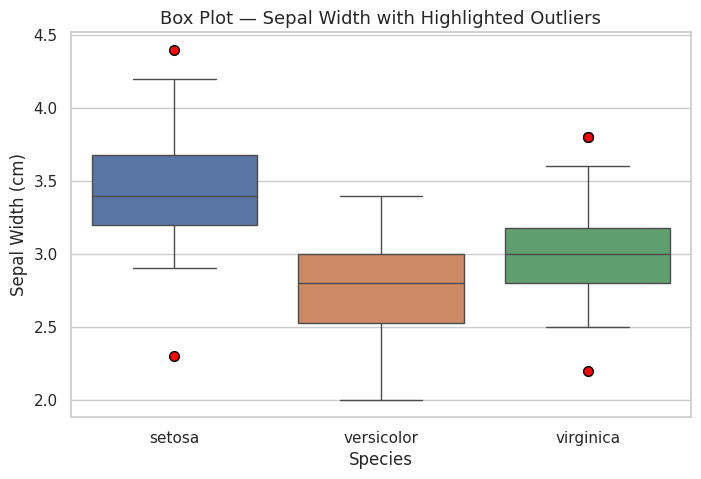

Red dots = outlier data points lying beyond 1.5 × IQR from Q1 or Q3.


In [14]:
# Highlighting outliers with custom marker style
flier_props = dict(marker='o', markerfacecolor='red', markersize=7,
                   markeredgecolor='black', linestyle='none')

plt.figure(figsize=(8, 5))
sns.boxplot(x='species', y='sepal_width', data=dataset,
            palette=['#4C72B0', '#DD8452', '#55A868'],
            flierprops=flier_props)
plt.title('Box Plot — Sepal Width with Highlighted Outliers', fontsize=13)
plt.xlabel('Species')
plt.ylabel('Sepal Width (cm)')
plt.show()

print("Red dots = outlier data points lying beyond 1.5 × IQR from Q1 or Q3.")

### Plot 7 — Horizontal Box Plot

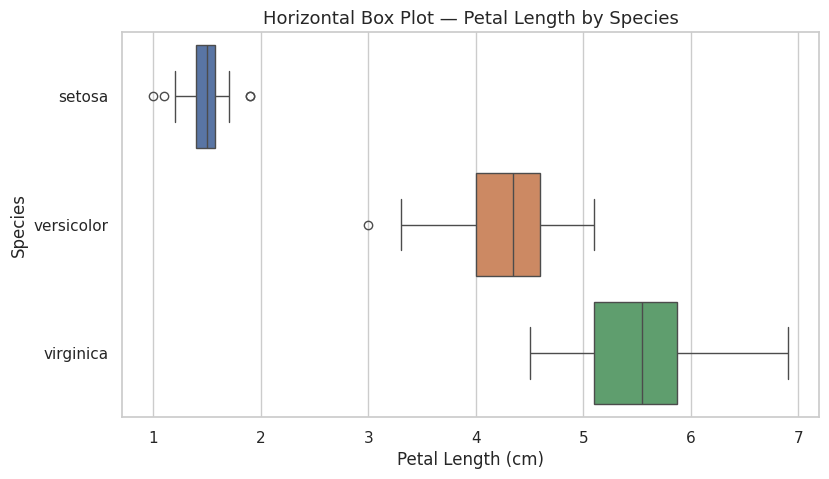

In [15]:
plt.figure(figsize=(9, 5))
sns.boxplot(x='petal_length', y='species', data=dataset,
            palette=['#4C72B0', '#DD8452', '#55A868'],
            orient='h')
plt.title('Horizontal Box Plot — Petal Length by Species', fontsize=13)
plt.xlabel('Petal Length (cm)')
plt.ylabel('Species')
plt.show()

### Plot 8 — Box Plot Overlaid with Strip Plot (for individual data visibility)

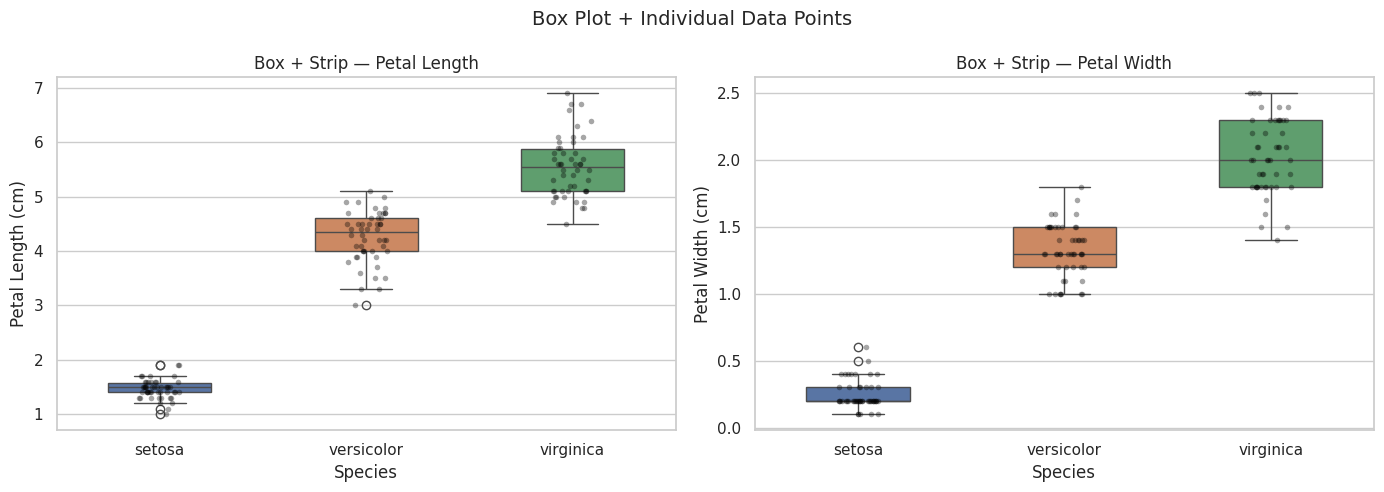

Black dots = individual data points overlaid on box plots for complete visibility.


In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, feat, title in zip(axes,
                           ['petal_length', 'petal_width'],
                           ['Petal Length', 'Petal Width']):
    sns.boxplot(x='species', y=feat, data=dataset,
                palette=['#4C72B0', '#DD8452', '#55A868'],
                width=0.5, ax=ax)
    sns.stripplot(x='species', y=feat, data=dataset,
                  color='black', alpha=0.35, jitter=True, size=4, ax=ax)
    ax.set_title(f'Box + Strip — {title}', fontsize=12)
    ax.set_xlabel('Species')
    ax.set_ylabel(f'{title} (cm)')

plt.suptitle('Box Plot + Individual Data Points', fontsize=14)
plt.tight_layout()
plt.show()

print("Black dots = individual data points overlaid on box plots for complete visibility.")

---
## 4. Statistical Summary per Species

In [17]:
print("=== Per-Species Statistical Summary ===")
for species in dataset['species'].unique():
    print(f"\n--- {species.upper()} ---")
    print(dataset[dataset['species'] == species]
          [['sepal_length', 'sepal_width', 'petal_length', 'petal_width']]
          .describe().round(2))

=== Per-Species Statistical Summary ===

--- SETOSA ---
       sepal_length  sepal_width  petal_length  petal_width
count         50.00        50.00         50.00        50.00
mean           5.01         3.43          1.46         0.25
std            0.35         0.38          0.17         0.11
min            4.30         2.30          1.00         0.10
25%            4.80         3.20          1.40         0.20
50%            5.00         3.40          1.50         0.20
75%            5.20         3.68          1.58         0.30
max            5.80         4.40          1.90         0.60

--- VERSICOLOR ---
       sepal_length  sepal_width  petal_length  petal_width
count         50.00        50.00         50.00        50.00
mean           5.94         2.77          4.26         1.33
std            0.52         0.31          0.47         0.20
min            4.90         2.00          3.00         1.00
25%            5.60         2.52          4.00         1.20
50%            5.90     

In [18]:
# IQR for each feature per species
print("=== IQR (Q3 - Q1) per Feature per Species ===")
features = ['sepal_length', 'sepal_width', 'petal_length', 'petal_width']
iqr_df = dataset.groupby('species')[features].apply(
    lambda x: x.quantile(0.75) - x.quantile(0.25)
)
print(iqr_df.round(3))

=== IQR (Q3 - Q1) per Feature per Species ===
            sepal_length  sepal_width  petal_length  petal_width
species                                                         
setosa             0.400        0.475         0.175          0.1
versicolor         0.700        0.475         0.600          0.3
virginica          0.675        0.375         0.775          0.5


---
## 5. Outlier Detection using IQR Method

In [19]:
print("=== Outlier Count per Feature (IQR Method, 1.5×IQR rule) ===")
for feat in features:
    Q1 = dataset[feat].quantile(0.25)
    Q3 = dataset[feat].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = dataset[(dataset[feat] < lower) | (dataset[feat] > upper)]
    print(f"  {feat:15s}: {len(outliers)} outlier(s)  "
          f"[valid range: {lower:.2f} — {upper:.2f}]")

=== Outlier Count per Feature (IQR Method, 1.5×IQR rule) ===
  sepal_length   : 0 outlier(s)  [valid range: 3.15 — 8.35]
  sepal_width    : 4 outlier(s)  [valid range: 2.05 — 4.05]
  petal_length   : 0 outlier(s)  [valid range: -3.65 — 10.35]
  petal_width    : 0 outlier(s)  [valid range: -1.95 — 4.05]


---
## Conclusion

Box plots on the Iris dataset reveal the following key patterns:

1. **Petal length and petal width** are the most discriminative features — the three species are clearly separated with minimal overlap, making these the best candidates for classification.

2. **Setosa** is the most distinct species across all four features. It has very short, narrow petals (tight IQR = low variance) and wide sepals.

3. **Versicolor and Virginica** overlap slightly in petal dimensions but are still largely separable. Virginica consistently has larger measurements.

4. **Sepal width** is the weakest discriminator — versicolor and virginica have nearly identical distributions for this feature.

5. **Outliers** are primarily found in sepal width (setosa), but the dataset is generally clean with no extreme anomalies.

6. The box plot is a powerful tool for **simultaneously visualizing central tendency, spread, skewness, and outliers** across multiple categories in a compact form.